Calculating Pearson correlation coefficients and relative mean squared errors of stellar masses estimates in our sample (see *oursample.ipynb*).

The code was written by Mária Pálfi (marika97@student.elte.hu).

#### Preparations

In [1]:
# importing useful packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style('white') # set figure style
from scipy.stats import pearsonr

In [2]:
# reading the file to dataframe
check = pd.read_csv( '../check_sm.txt', delimiter = '\t', low_memory = False )
check.head()

,ID,2MASS,wiseX,type,ra,dec,K,K_err,W1,W1_err,...,log_sm,d_log_sm,fluxscale,log_gama_sm,log_sm_lambdar,d_log_sm_lambdar,fluxscale_lambdar,log_gama_sm_lambdar,sm,log_gama_sm_magphys
0,260,12125210+0117588,J121252.11+011758.9,G,183.217087,1.299673,7.953,0.015,8.868,NaN,...,10.67840,0.104434,1.077330,10.740281,10.67200,0.108565,1.076980,10.733740,26270000000,10.419460
1,1025,14463127+0116286,J144631.24+011629.2,G,221.630325,1.274620,10.528,0.048,10.926,NaN,...,11.08790,0.110348,1.165130,11.183806,11.08410,0.112150,1.255260,11.212366,126100000000,11.100715
2,1656,14441893+0002312,J144418.90+000230.8,G,221.078888,0.042021,11.229,0.071,11.679,NaN,...,10.69100,0.109208,1.254340,10.818947,10.68640,0.119500,0.984636,10.709208,33090000000,10.519697
3,1899,12024266+0157083,J120242.71+015707.2,G,180.677765,1.952326,11.402,0.075,12.060,NaN,...,10.44000,0.113381,0.875903,10.411988,10.41900,0.107483,1.071390,10.478480,28080000000,10.448397
4,2791,08360330+0119469,J083603.32+011947.2,G,129.013763,1.329719,12.066,0.081,12.225,0.023,...,9.83516,0.115833,1.112100,9.910836,9.84532,0.109942,1.118270,9.923399,3542000000,9.549249


In [3]:
print( 'Length of our sample: ', len(check) )

Length of our sample:  4342


#### Pearson correlation coefficients

In [4]:
# creating a dataframe with base-10 log of the stellar mass estimates
to_corr = pd.DataFrame( { 'Jarrett': np.log10(check.SMass_Jarrett),
                          'Cluver': np.log10(check.SMass_Cluver), 
                          'Kettlety': np.log10(check.SMass_Kettlety),
                          'Cappellari': np.log10(check.SMass_Cappellari),
                          'GAMA': check.log_gama_sm, 
                          'LAMBDAR': check.log_gama_sm_lambdar, 
                          'MAGPHYS': check.log_gama_sm_magphys } )

In [5]:
# calculating Pearson correlation coefficients
to_corr.corr(method='pearson')

,Jarrett,Cluver,Kettlety,Cappellari,GAMA,LAMBDAR,MAGPHYS
Jarrett,1.000000,0.998944,0.778735,0.731045,0.822463,0.822341,0.805535
Cluver,0.998944,1.000000,0.804585,0.758523,0.840003,0.839625,0.824632
Kettlety,0.778735,0.804585,1.000000,0.920951,0.888358,0.887083,0.890904
Cappellari,0.731045,0.758523,0.920951,1.000000,0.885115,0.880160,0.888964
GAMA,0.822463,0.840003,0.888358,0.885115,1.000000,0.994258,0.950708
LAMBDAR,0.822341,0.839625,0.887083,0.880160,0.994258,1.000000,0.950540
MAGPHYS,0.805535,0.824632,0.890904,0.888964,0.950708,0.950540,1.000000


In [6]:
# creating a dataframe with the stellar mass estimates
to_corr = pd.DataFrame( { 'Jarrett': check.SMass_Jarrett,
                          'Cluver': check.SMass_Cluver, 
                          'Kettlety': check.SMass_Kettlety,
                          'Cappellari': check.SMass_Cappellari,
                          'GAMA': 10**check.log_gama_sm, 
                          'LAMBDAR': 10**check.log_gama_sm_lambdar, 
                          'MAGPHYS': 10**check.log_gama_sm_magphys } )

In [7]:
# calculating Pearson correlation coefficients
to_corr.corr(method='pearson')

,Jarrett,Cluver,Kettlety,Cappellari,GAMA,LAMBDAR,MAGPHYS
Jarrett,1.000000,0.998880,0.724470,0.660200,0.696913,0.683222,0.770376
Cluver,0.998880,1.000000,0.746412,0.687322,0.713812,0.699324,0.790078
Kettlety,0.724470,0.746412,1.000000,0.813756,0.717878,0.702409,0.807143
Cappellari,0.660200,0.687322,0.813756,1.000000,0.723891,0.698882,0.802042
GAMA,0.696913,0.713812,0.717878,0.723891,1.000000,0.983651,0.820224
LAMBDAR,0.683222,0.699324,0.702409,0.698882,0.983651,1.000000,0.805172
MAGPHYS,0.770376,0.790078,0.807143,0.802042,0.820224,0.805172,1.000000


It gave the same results as for the logarithms of the values.

Taking into account the uncertainty of the $M_\ast$ values from IR-based methods with Monte-Carlo simulation.

We are using the base-10 logarithms of stellar masses, uncertainty of log values:

$$X = \log_{10}(x)$$
$$\delta X = \frac{\partial X}{\partial x} \delta x$$
$$\delta X = \frac{\partial [\log_{10}(x)]}{\partial x} \delta x = \frac{1}{ln(10)} \cdot \frac{\delta x}{x} $$

In [8]:
c = 1/np.log(10)

In [9]:
# saving stellar mass values and uncertainties to a dataframe
to_corr = pd.DataFrame( { 'Jarrett': np.log10(check.SMass_Jarrett),
                          'errJarrett': c*check.err_SMass_Jarrett,
                          'Cluver': np.log10(check.SMass_Cluver), 
                          'errCluver': c*check.err_SMass_Cluver,
                          'Kettlety': np.log10(check.SMass_Kettlety),
                          'errKettlety': c*check.err_SMass_Kettlety,
                          'Cappellari': np.log10(check.SMass_Cappellari),
                          'errCappellari': c*check.err_SMass_Cappellari,
                          'GAMA': check.log_gama_sm, 
                          'LAMBDAR': check.log_gama_sm_lambdar, 
                          'MAGPHYS': check.log_gama_sm_magphys } )

In [10]:
# Monte Carlo simulation
def MC_Pearson( x, xerr, y, yerr, length, print=True ):
    n = 10000 # Let's do 10,000 simulations
    rho_sim = np.zeros(n) # Initialize array of Pearson correlation coefficients
    p_sim = np.zeros(n) # Initialize array of p-values
    
    for i in range(n):
        # Generate random weights using mean weights with measurement error
        x_sim = np.random.normal( x, xerr, length )
        y_sim = np.random.normal( y, yerr, length )
        
        # Calculate correlation coefficient and p-value
        rho_sim[i],p_sim[i] = pearsonr(x_sim,y_sim)
    if print == True:
        print( 'Pearson correlation coefficient is ' + str(np.mean(rho_sim)) + ' +/- ' \
                + str(np.std(rho_sim)) + ', pvalue=' + str(np.std(p_sim)) )
    return np.mean(rho_sim), np.std(rho_sim), np.std(p_sim)

In [11]:
# empty arrays to dave results
ccorr = np.zeros( [7,7] )
ecorr = np.zeros( [7,7] )
pcorr = np.zeros( [7,7] )

In [12]:
# saving stellar mass values to a list 
to_corr_arr_val = [ to_corr.Jarrett, to_corr.Cluver, to_corr.Kettlety, to_corr.Cappellari, to_corr.GAMA, to_corr.LAMBDAR, to_corr.MAGPHYS ]
# saving errors to a list, assuming GAMA stellar masses have have no uncertainty
to_corr_arr_err = [ to_corr.errJarrett, to_corr.errCluver, to_corr.errKettlety, to_corr.errCappellari, 
                   np.zeros(len( to_corr )), np.zeros(len( to_corr )), np.zeros(len( to_corr )) ]

In [13]:
# running the Monte-Carlo simulation
for i in range(0, 7):
    for j in range(0, i+1):
        print( i, j )
        ccorr[i,j], ecorr[i,j], pcorr[i,j] = MC_Pearson( to_corr_arr_val[i], to_corr_arr_err[j],
                                                         to_corr_arr_val[j], to_corr_arr_err[j],
                                                         len(to_corr), print = False )

0 0
1 0
1 1
2 0
2 1
2 2
3 0
3 1
3 2
3 3
4 0
4 1
4 2
4 3
4 4
5 0
5 1
5 2
5 3
5 4
5 5
6 0
6 1
6 2
6 3
6 4
6 5
6 6


In [14]:
# Saving correlation coefficients to a dataframe
ccorr = pd.DataFrame( data = ccorr )
ccorr

,0,1,2,3,4,5,6
0,0.928099,0.000000,0.000000,0.000000,0.000000,0.00000,0.0
1,0.925858,0.941811,0.000000,0.000000,0.000000,0.00000,0.0
2,0.725652,0.760899,0.812536,0.000000,0.000000,0.00000,0.0
3,0.686024,0.721380,0.764239,0.950637,0.000000,0.00000,0.0
4,0.771625,0.798595,0.736368,0.841142,1.000000,0.00000,0.0
5,0.772026,0.798768,0.736908,0.837003,0.994258,1.00000,0.0
6,0.755487,0.783846,0.737705,0.844478,0.950708,0.95054,1.0


In [15]:
# errors of correlation coefficients
ecorr

array([[2.40951375e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.48281688e-03, 2.25494571e-03, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.54167930e-03, 3.80103151e-03, 4.64014084e-03, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.08240811e-03, 3.63670571e-03, 5.04125605e-03, 1.50961173e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.53466950e-03, 3.32684714e-03, 5.77073154e-03, 2.67055653e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.55201044e-03, 3.29907062e-03, 5.76509571e-03, 2.73425803e-03,
        2.22044605e-16, 0.00000000e+00, 0.00000000e+00],
       [4.67707576e-03, 3.41496952e-03, 5.57074011e-03, 2.70806840e-03,
        0.00000000e+00, 3.33066907e-16, 0.00000000e+00]])

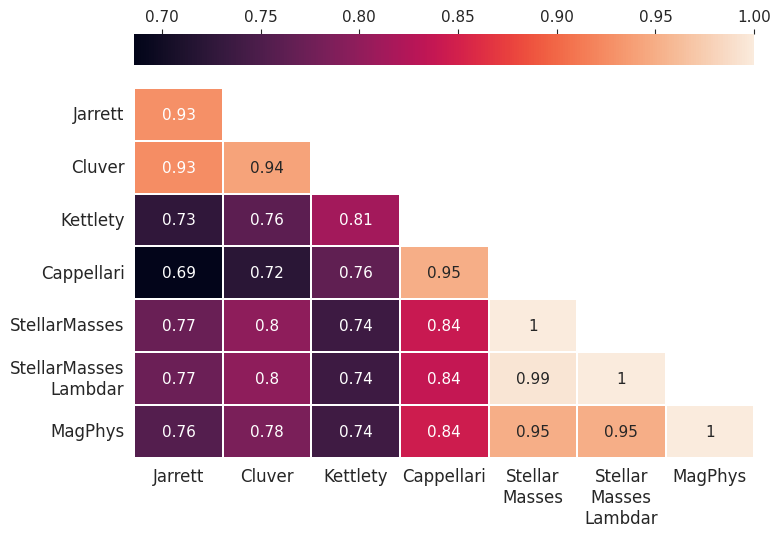

In [16]:
# Heatmap of the correlations
names_y = [ 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari', 'StellarMasses', 'StellarMasses\nLambdar', 'MagPhys' ]
names_x = [ 'Jarrett', 'Cluver', 'Kettlety', 'Cappellari', 'Stellar\nMasses', 'Stellar\nMasses\nLambdar', 'MagPhys' ]
fig = plt.figure( figsize = (8,6), dpi = 100 )
mask = np.triu(np.ones_like( ccorr, dtype=bool ))
np.fill_diagonal( mask, False )
dataplot = sns.heatmap( ccorr, annot = True, fmt = '.2g', annot_kws=dict(fontsize = 11),
                       linewidth=.1, mask = mask,
                       cbar_kws = dict(use_gridspec=False,location="top"),
                       xticklabels = names_x, yticklabels = names_y )
dataplot.tick_params(left=False, bottom=False)
dataplot.set_xticklabels( dataplot.get_xmajorticklabels(), fontsize = 12 )
dataplot.set_yticklabels( dataplot.get_ymajorticklabels(), fontsize = 12 )
cbar = dataplot.collections[0].colorbar
cbar.ax.tick_params(labelsize = 11)
plt.xticks(rotation=0) 
plt.savefig( '../correlations_pearson.eps', format = 'eps', dpi = 100, bbox_inches='tight' )
plt.show() 

#### Relative mean squared error

$$D = \frac{1}{N} \sum\limits_{i} \frac{(x_i-m_i)^2}{m_i^2}$$

In [17]:
def D( x, y, factor = 7 ):
    Y = 10**( y - factor )
    return ( 10**( x - factor ) - Y )**2 / ( Y**2 * len(to_corr) ) 

In [18]:
def printer( val, label = 'label', hist = True, bin = np.linspace( 0, 200, 50 ) ):
    print( 'Sum: ', np.sum( val ) )
    print( 'Mean: ', np.mean( val ) )
    print( 'STD: ', np.std( val ) )
    print( 'Median: ', np.median( val ) )
    print( 'Max: ', np.max( val ) )
    print( 'Min: ', np.min( val ) )
    
    if hist == True:
        plt.hist( val, bins = bin, histtype = 'step', density=True, label = label );

Cluver:
Sum:  0.5881782102018489
Mean:  0.000135462508107289
STD:  0.002990404326201062
Median:  2.4676963257981353e-05
Max:  0.17608585783183028
Min:  2.06883467886437e-11

Jarrett:
Sum:  0.4537467951864682
Mean:  0.00010450179529858779
STD:  0.0009204644971533832
Median:  7.66616450661222e-05
Max:  0.054729624937638735
Min:  1.0353308366096203e-10

Kettlety:
Sum:  1.844185695723438
Mean:  0.0004247318506963238
STD:  0.014985463494341756
Median:  3.2345102598332434e-05
Max:  0.9358602926244256
Min:  4.524483311993092e-11

Cappellari:
Sum:  30.96861724337113
Mean:  0.007132339300638215
STD:  0.16127710146901644
Median:  0.001063020902745143
Max:  8.685346230057997
Min:  5.709271300309462e-08


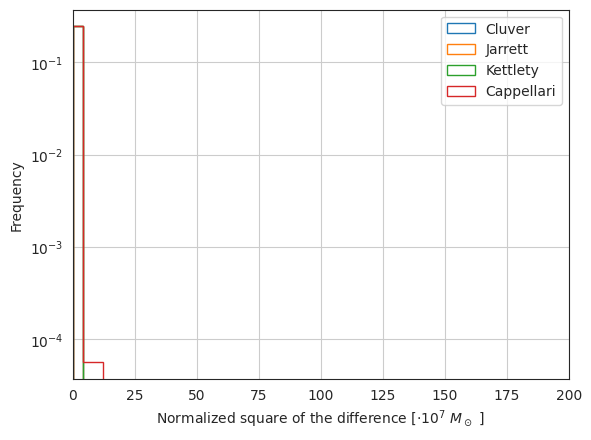

In [19]:
D_Cluver_GAMA = D( to_corr.Cluver, to_corr.GAMA, factor = 0 )
D_Jarrett_GAMA = D( to_corr.Jarrett, to_corr.GAMA, factor = 0 )
D_Kettlety_GAMA = D( to_corr.Kettlety, to_corr.GAMA, factor = 0 )
D_Cappellari_GAMA = D( to_corr.Cappellari, to_corr.GAMA, factor = 0 )

plt.grid()
print( 'Cluver:' )
printer( D_Cluver_GAMA, label = 'Cluver' )
print( '\nJarrett:' )
printer( D_Jarrett_GAMA, label = 'Jarrett' )
print( '\nKettlety:' )
printer( D_Kettlety_GAMA, label = 'Kettlety' )
print( '\nCappellari:' )
printer( D_Cappellari_GAMA, label = 'Cappellari' )
plt.xlim( 0, 200 )
plt.yscale('log')
plt.xlabel( 'Normalized square of the difference [$\cdot 10^7 ~ M_\odot$ ]' )
plt.ylabel( 'Frequency' )
plt.legend();

Cluver:
Sum:  0.5748798851405392
Mean:  0.000132399789299986
STD:  0.003144880075110647
Median:  2.759341891196472e-05
Max:  0.19161307208621955
Min:  1.6582453507549987e-10

Jarrett:
Sum:  0.4653243284477172
Mean:  0.00010716820093222413
STD:  0.0009812539280785167
Median:  8.120000794189643e-05
Max:  0.059692268956027826
Min:  3.7725848716932206e-11

Kettlety:
Sum:  1.3810082346675776
Mean:  0.00031805809181657704
STD:  0.010577694720623356
Median:  3.6841506381931526e-05
Max:  0.6598301744836941
Min:  3.6560128039544556e-12

Cappellari:
Sum:  26.75758569922496
Mean:  0.006162502464123667
STD:  0.15199588981751172
Median:  0.0009491693306572437
Max:  9.427823368730783
Min:  4.323694263156538e-09


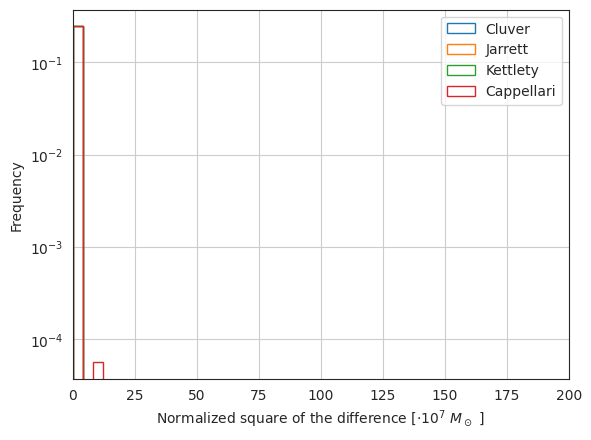

In [20]:
D_Cluver_GAMA = D( to_corr.Cluver, to_corr.LAMBDAR, factor = 0 )
D_Jarrett_GAMA = D( to_corr.Jarrett, to_corr.LAMBDAR, factor = 0 )
D_Kettlety_GAMA = D( to_corr.Kettlety, to_corr.LAMBDAR, factor = 0 )
D_Cappellari_GAMA = D( to_corr.Cappellari, to_corr.LAMBDAR, factor = 0 )

plt.grid()
print( 'Cluver:' )
printer( D_Cluver_GAMA, label = 'Cluver' )
print( '\nJarrett:' )
printer( D_Jarrett_GAMA, label = 'Jarrett' )
print( '\nKettlety:' )
printer( D_Kettlety_GAMA, label = 'Kettlety' )
print( '\nCappellari:' )
printer( D_Cappellari_GAMA, label = 'Cappellari' )
plt.xlim( 0, 200 )
plt.yscale('log')
plt.xlabel( 'Normalized square of the difference [$\cdot 10^7 ~ M_\odot$ ]' )
plt.ylabel( 'Frequency' )
plt.legend();

Cluver:
Sum:  1.005275416639983
Mean:  0.00023152358743435815
STD:  0.008001249809339223
Median:  2.316114648518042e-05
Max:  0.5205423257284403
Min:  2.7579683855823116e-11

Jarrett:
Sum:  0.4871840656841717
Mean:  0.0001122026867075476
STD:  0.0025456120214928444
Median:  5.427559578207149e-05
Max:  0.16556308020762603
Min:  7.958778497601635e-13

Kettlety:
Sum:  0.9872019550417068
Mean:  0.0002273611135517519
STD:  0.007642379545566089
Median:  1.9129441610040507e-05
Max:  0.4858031159559115
Min:  2.6227343823874203e-13

Cappellari:
Sum:  47.60923695597291
Mean:  0.010964817355129643
STD:  0.38031343222706654
Median:  0.0020577722498626157
Max:  25.036409634668313
Min:  2.4310272292471336e-07


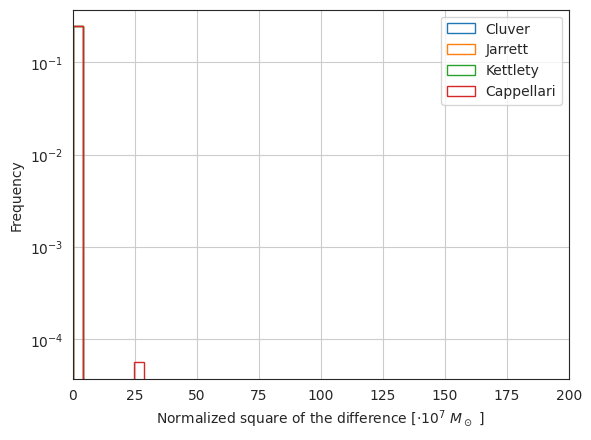

In [21]:
D_Cluver_GAMA = D( to_corr.Cluver, to_corr.MAGPHYS, factor = 0 )
D_Jarrett_GAMA = D( to_corr.Jarrett, to_corr.MAGPHYS, factor = 0 )
D_Kettlety_GAMA = D( to_corr.Kettlety, to_corr.MAGPHYS, factor = 0 )
D_Cappellari_GAMA = D( to_corr.Cappellari, to_corr.MAGPHYS, factor = 0 )

plt.grid()
print( 'Cluver:' )
printer( D_Cluver_GAMA, label = 'Cluver' )
print( '\nJarrett:' )
printer( D_Jarrett_GAMA, label = 'Jarrett' )
print( '\nKettlety:' )
printer( D_Kettlety_GAMA, label = 'Kettlety' )
print( '\nCappellari:' )
printer( D_Cappellari_GAMA, label = 'Cappellari' )
plt.xlim( 0, 200 )
plt.yscale('log')
plt.xlabel( 'Normalized square of the difference [$\cdot 10^7 ~ M_\odot$ ]' )
plt.ylabel( 'Frequency' )
plt.legend();